In [1]:
# Verify all packages are installed
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, Descriptors
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f"✅ RDKit Version: {Chem.rdBase.rdkitVersion}")
print(f"✅ Pandas: {pd.__version__}")
print(f"✅ Scikit-learn: available")
print("🚀 All imports successful!")

✅ RDKit Version: 2026.03.1
✅ Pandas: 2.3.3
✅ Scikit-learn: available
🚀 All imports successful!


In [2]:
# Load the ESOL Solubility Dataset (Standard Benchmark)
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)

print(f"📊 Dataset Loaded: {len(df)} compounds")
print(f"📈 Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

📊 Dataset Loaded: 1128 compounds
📈 Columns: ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

First 5 rows:


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


✅ All imports successful!
📊 Dataset Loaded: 1128 compounds
⏳ Generating fingerprints...
⏳ Generating descriptors...
✅ Features Ready: X shape = (1128, 2053), y shape = (1128,)
   Fingerprints: 2048 | Descriptors: 5 | Total: 2053 features
   Train: 1009 samples | Test: 119 samples
⏳ Training model...
✅ Model Trained!

📈 Results:
   RMSE: 0.838
   R² Score: 0.805


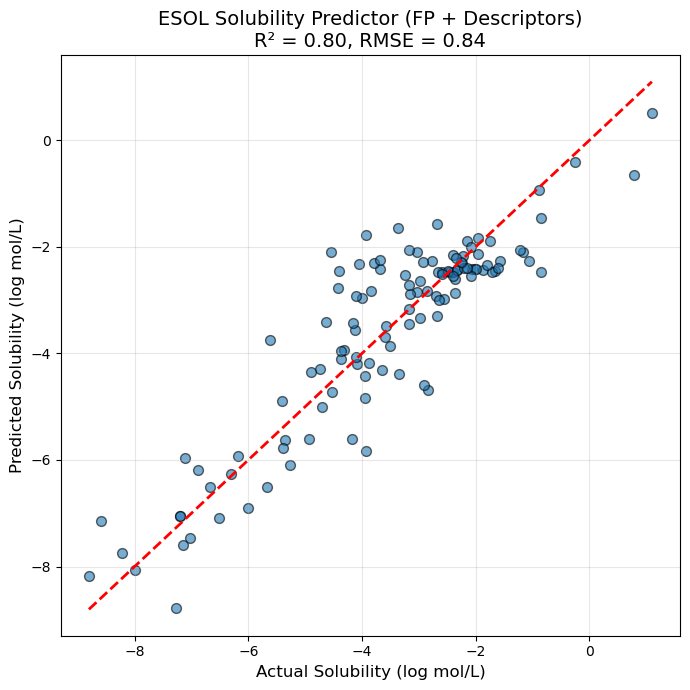


🔍 Top 10 Features by Importance:
   1. Descriptor 'LogP': 0.8152
   2. Descriptor 'MW': 0.0681
   3. Descriptor 'TPSA': 0.0212
   4. Descriptor 'HBA': 0.0043
   5. Fingerprint Bit 1602: 0.0029
   6. Fingerprint Bit 807: 0.0024
   7. Fingerprint Bit 1380: 0.0023
   8. Fingerprint Bit 486: 0.0023
   9. Descriptor 'HBD': 0.0018
   10. Fingerprint Bit 378: 0.0017


In [14]:
# === IMPORTS ===
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

print("✅ All imports successful!")

# === LOAD DATA ===
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(url)
print(f"📊 Dataset Loaded: {len(df)} compounds")

# === FEATURIZATION: FINGERPRINTS ===
from rdkit.Chem import rdFingerprintGenerator

def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
        return gen.GetFingerprint(mol)
    return None

print("⏳ Generating fingerprints...")
df['Fingerprint'] = df['smiles'].apply(get_fingerprint)
X_fp = np.array([list(fp) for fp in df['Fingerprint']])

# === FEATURIZATION: DESCRIPTORS ===
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return [np.nan]*5
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol)
    ]

print("⏳ Generating descriptors...")
desc_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
df[desc_cols] = df['smiles'].apply(lambda s: pd.Series(get_descriptors(s)))

# Impute any NaN values in descriptors
desc_array = SimpleImputer().fit_transform(df[desc_cols].values)

# === COMBINE FINGERPRINTS + DESCRIPTORS ===
X_combined = np.hstack([X_fp, desc_array])
y = df['measured log solubility in mols per litre'].values

print(f"✅ Features Ready: X shape = {X_combined.shape}, y shape = {y.shape}")
print(f"   Fingerprints: 2048 | Descriptors: 5 | Total: 2053 features")


from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import GroupShuffleSplit

# Generate Bemis-Murcko scaffolds
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold) if scaffold else "unknown"
    return "unknown"

df['scaffold'] = df['smiles'].apply(get_scaffold)

# Split by scaffold (not random)
splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['scaffold']))

X_train, X_test = X_combined[train_idx], X_combined[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# === TRAIN/TEST SPLIT (AFTER combining features!) ===
#X_train, X_test, y_train, y_test = train_test_split(
#    X_combined, y, test_size=0.2, random_state=42
#)
print(f"   Train: {len(X_train)} samples | Test: {len(X_test)} samples")

# === TRAIN MODEL ===
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("⏳ Training model...")
model.fit(X_train, y_train)
print("✅ Model Trained!")

# === EVALUATE ===
y_pred = model.predict(X_test)  # Now X_test has 2053 features, matching training
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n📈 Results:")
print(f"   RMSE: {rmse:.3f}")
print(f"   R² Score: {r2:.3f}")

# === VISUALIZE ===
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Solubility (log mol/L)", fontsize=12)
plt.ylabel("Predicted Solubility (log mol/L)", fontsize=12)
plt.title(f"ESOL Solubility Predictor (FP + Descriptors)\nR² = {r2:.2f}, RMSE = {rmse:.2f}", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === FEATURE IMPORTANCE (Top 10) ===
importances = model.feature_importances_
top_indices = np.argsort(importances)[-10:][::-1]

print(f"\n🔍 Top 10 Features by Importance:")
for i, idx in enumerate(top_indices):
    if idx < 2048:
        print(f"   {i+1}. Fingerprint Bit {idx}: {importances[idx]:.4f}")
    else:
        desc_idx = idx - 2048
        print(f"   {i+1}. Descriptor '{desc_cols[desc_idx]}': {importances[idx]:.4f}")

In [15]:
# Save model and metadata (for GitHub portfolio)
import joblib

joblib.dump(model, 'solubility_model.pkl')
df.to_csv('esol_data_processed.csv', index=False)

print("✅ Model saved: solubility_model.pkl")
print("✅ Data saved: esol_data_processed.csv")
print("\n📁 These files can be uploaded to GitHub for your portfolio!")

✅ Model saved: solubility_model.pkl
✅ Data saved: esol_data_processed.csv

📁 These files can be uploaded to GitHub for your portfolio!
